Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC3084 - Data Science  

Cristian Tunchez (231359)  
Nadissa Vela (23764)

# Laboratorio 2: Deep Learning

## Ejercicio 2 — Exploración de similitud entre series con catch22

Este notebook toma **las 7 series** construidas en el Laboratorio 1 (la serie total, las 3
regiones geográficas y las 3 fronteras), les extrae las 22 características de catch22 y
usa esa representación para responder qué tan parecidas son entre sí.

Se cubren los incisos **2.1 a 2.13**. El inciso 2.14, que pide un modelo LSTM alimentado con
características de catch22, está en `03_lstm_catch22.ipynb`.

## Configuración del entorno

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from statsmodels.tsa.stattools import acf

import data_utils as du
import catch22_utils as c22
import ts_utils as tsu

SEMILLA = 42
np.random.seed(SEMILLA)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4),
    "axes.titlesize": 12, "axes.titleweight": "bold",
})
MILES = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
pd.set_option("display.max_columns", 40)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. ¿Qué es catch22 y por qué importa? (inciso 2.1)

Cuando se quiere comparar series de tiempo entre sí, el problema es que una serie es una
lista larga de números y dos series pueden tener longitudes, escalas y unidades distintas.
Comparar valor por valor no dice mucho.

La idea de **catch22** (*CAnonical Time-series CHaracteristics*) es reemplazar cada serie
completa por un **vector corto de 22 números** que resumen *cómo se comporta*: qué tan
autocorrelacionada está, qué tan asimétrica es su distribución, si tiene periodicidad, qué
tan largas son sus rachas por encima de la media, qué tan predecible es, etc.

El conjunto no se eligió a mano. Los autores partieron de una biblioteca de más de 7,000
características de series de tiempo (*hctsa*), descartaron las que fallaban o eran
demasiado sensibles, y se quedaron con las que:

- funcionaban bien para **clasificar** series en muchos problemas distintos,
- eran **rápidas de calcular**, y
- estaban **poco correlacionadas entre sí**, para no repetir la misma información.

Por qué importa:

1. **Convierte series en filas de una tabla.** Cada serie pasa a ser un punto en un espacio
   de 22 dimensiones, y ahí sí se pueden usar herramientas normales: PCA, clustering,
   distancias, correlaciones.
2. **Permite comparar series de escalas muy distintas.** La serie total mueve cientos de
   miles de viajeros y San Cristóbal decenas de miles; las características describen la
   forma del comportamiento, no la magnitud.
3. **Es interpretable.** Cada característica tiene un nombre y un significado, así que
   cuando dos series salen juntas en un grupo se puede decir *por qué*.

## 2. Extracción de las 22 características (incisos 2.2 y 2.3)

Se cargan las 7 series completas (entrenamiento + prueba, porque aquí interesa caracterizar el comportamiento histórico, no ajustar un modelo) y se les aplica `pycatch22`.

In [2]:
series = du.cargar_todas()
for clave, s in series.items():
    print(f"{du.NOMBRES[clave]:32} {len(s)} meses   "
          f"[{s.index.min():%Y-%m} a {s.index.max():%Y-%m}]   media = {s.mean():>9,.0f}")

Total (obligatoria)              210 meses   [2009-01 a 2026-06]   media =   222,438
Región: América del Centro       210 meses   [2009-01 a 2026-06]   media =   158,495
Región: América del Norte        210 meses   [2009-01 a 2026-06]   media =    43,623
Región: Europa                   210 meses   [2009-01 a 2026-06]   media =    10,235
Frontera: 01 La Aurora           210 meses   [2009-01 a 2026-06]   media =    90,428
Frontera: 07 Valle Nuevo         210 meses   [2009-01 a 2026-06]   media =    48,300
Frontera: 09 San Cristóbal       210 meses   [2009-01 a 2026-06]   media =    19,922


In [3]:
matriz = c22.matriz_catch22(series, du.NOMBRES)
print(f"Matriz de características: {matriz.shape[0]} series x {matriz.shape[1]} características\n")
display(matriz.style.format("{:.3f}"))

Matriz de características: 7 series x 22 características



,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total (obligatoria),0.083,0.342,8.965,3.000,0.352,-0.062,0.933,30.000,0.014,11.000,0.318,2.000,0.056,0.210,0.324,0.820,6.000,1.852,0.833,0.857,0.123,0.626
Región: América del Centro,0.391,0.128,8.866,3.000,0.400,-0.065,0.919,42.000,0.014,7.000,0.320,2.000,0.056,0.171,0.324,0.815,6.000,1.833,0.786,0.857,0.123,0.635
Región: América del Norte,0.311,-0.239,9.077,2.000,0.271,-0.012,0.943,12.000,0.036,3.000,0.277,1.000,0.038,0.829,0.324,0.740,5.000,2.053,0.167,0.738,0.098,0.722
Región: Europa,0.268,0.008,4.448,2.000,0.348,0.084,0.943,8.000,0.014,8.000,0.230,1.000,0.059,0.819,0.333,0.762,6.000,2.055,0.143,0.738,0.172,0.783
Frontera: 01 La Aurora,-0.401,-0.118,6.602,10.000,0.204,-0.163,0.947,34.000,0.010,11.000,0.212,9.000,0.071,0.188,0.324,0.759,5.000,2.001,0.857,0.857,0.172,0.738
Frontera: 07 Valle Nuevo,0.312,0.075,9.212,2.000,0.265,-0.092,0.923,38.000,0.039,7.000,0.302,1.000,0.056,0.162,0.329,0.792,6.000,1.854,0.143,0.833,0.123,0.655
Frontera: 09 San Cristóbal,0.584,-0.116,8.497,7.000,0.345,-0.046,0.871,31.000,0.070,7.000,0.243,6.000,0.048,0.200,-0.414,0.788,5.000,1.750,0.143,0.857,0.123,0.693


En esta matriz **cada fila es una serie y cada columna una de las 22 características**. Los nombres de las columnas son los identificadores originales de catch22; los más relevantes se explican más adelante, cuando aparezcan en los resultados.

## 3. Estandarización (inciso 2.4)

Las 22 características viven en escalas completamente distintas: algunas son proporciones
entre 0 y 1, otras son conteos y otras pueden ser grandes. Si se dejaran así, las de valores
grandes dominarían cualquier distancia o componente principal solo por su magnitud.

Se estandariza cada característica restándole su media y dividiéndola entre su desviación
estándar, calculadas **sobre las 7 series**. Después de esto, toda característica tiene
media 0 y desviación 1, y todas pesan lo mismo.

Antes de estandarizar se descartan las características que valen lo mismo en las 7 series:
al tener desviación cero, dividir entre ella produciría valores indefinidos.

In [4]:
matriz_util, descartadas = c22.quitar_constantes(matriz)
if descartadas:
    print(f"Características descartadas por ser constantes en las 7 series ({len(descartadas)}):")
    for c in descartadas:
        print(f"  - {c}")
else:
    print("Ninguna característica resultó constante: se conservan las 22.")

escalador = StandardScaler()
Z = escalador.fit_transform(matriz_util)
matriz_std = pd.DataFrame(Z, index=matriz_util.index, columns=matriz_util.columns)

print(f"\nMatriz estandarizada: {matriz_std.shape[0]} series x {matriz_std.shape[1]} características")
print(f"Media de cada característica: {matriz_std.mean().abs().max():.1e} (≈ 0)")
print(f"Desviación de cada característica: {matriz_std.std(ddof=0).mean():.3f} (= 1)")
matriz_std.to_csv("../data/processed/matriz_catch22.csv")
print("Guardado: data/processed/matriz_catch22.csv")

Ninguna característica resultó constante: se conservan las 22.



Matriz estandarizada: 7 series x 22 características
Media de cada característica: 3.3e-15 (≈ 0)
Desviación de cada característica: 1.000 (= 1)


Guardado: data/processed/matriz_catch22.csv


## 4. Análisis de la matriz (inciso 2.5)

### 4.1 Análisis de Componentes Principales (PCA)

El PCA busca combinaciones de las 22 características que capturen la mayor variación posible
entre las series, para poder dibujarlas en dos dimensiones. Con 7 series el número máximo de
componentes es 6.

In [5]:
pca = PCA(n_components=min(6, matriz_std.shape[0] - 1), random_state=SEMILLA)
coords = pca.fit_transform(matriz_std.values)

varianza = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(pca.n_components_)],
    "varianza explicada": pca.explained_variance_ratio_,
    "acumulada": np.cumsum(pca.explained_variance_ratio_),
})
display(varianza.style.format({"varianza explicada": "{:.1%}", "acumulada": "{:.1%}"}).hide(axis="index"))
print(f"PC1 + PC2 explican el {varianza.iloc[1]['acumulada']:.1%} de la variación entre series.")

componente,varianza explicada,acumulada
PC1,33.9%,33.9%
PC2,29.1%,63.0%
PC3,21.5%,84.6%
PC4,10.4%,95.0%
PC5,3.2%,98.2%
PC6,1.8%,100.0%


PC1 + PC2 explican el 63.0% de la variación entre series.


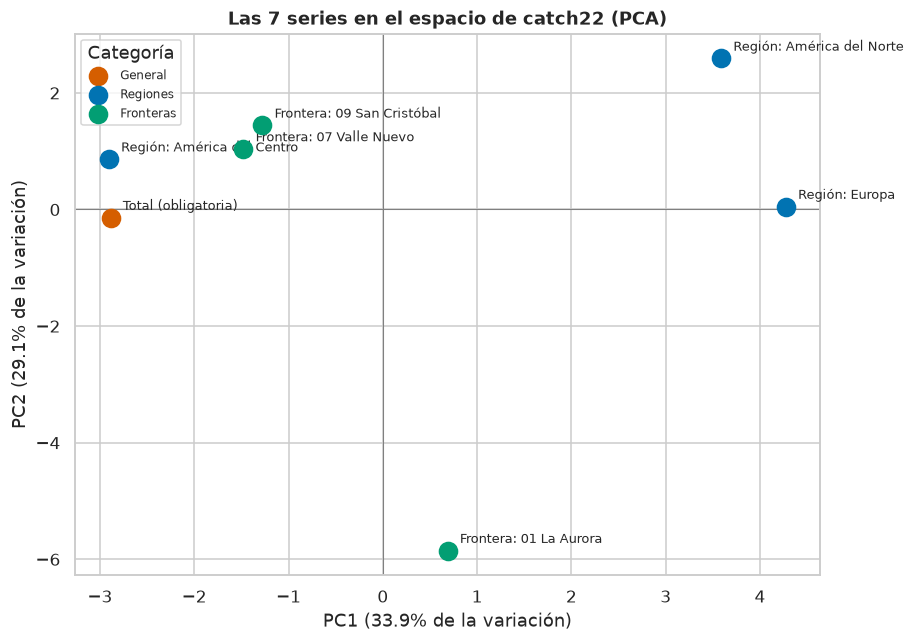

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 6))
colores = {"General": "C3", "Regiones": "C0", "Fronteras": "C2"}
for i, etiqueta in enumerate(matriz_std.index):
    clave = [k for k, v in du.NOMBRES.items() if v == etiqueta][0]
    cat = du.CATEGORIAS[clave]
    ax.scatter(coords[i, 0], coords[i, 1], s=140, color=colores[cat], zorder=3,
               label=cat if cat not in ax.get_legend_handles_labels()[1] else None)
    ax.annotate(etiqueta, (coords[i, 0], coords[i, 1]), fontsize=8.5,
                xytext=(8, 5), textcoords="offset points")
ax.axhline(0, color="grey", lw=0.7); ax.axvline(0, color="grey", lw=0.7)
ax.set(title="Las 7 series en el espacio de catch22 (PCA)",
       xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} de la variación)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} de la variación)")
ax.legend(title="Categoría", fontsize=8)
plt.tight_layout()
plt.show()

En este gráfico, **dos series cercanas se comportan de forma parecida** según las 22
características. El color indica a qué categoría del Laboratorio 1 pertenece cada serie.

### 4.2 Clustering

Se agrupan las series de dos formas complementarias:

- **Jerárquico (dendrograma):** empieza con cada serie sola y va uniendo las más parecidas.
  El eje vertical indica qué tan distintas eran las series al momento de unirse.
- **K-medias:** parte el conjunto en un número fijo de grupos. Para elegir ese número se usa
  el *coeficiente de silueta*, que mide qué tan bien separados quedan los grupos (más alto es
  mejor).

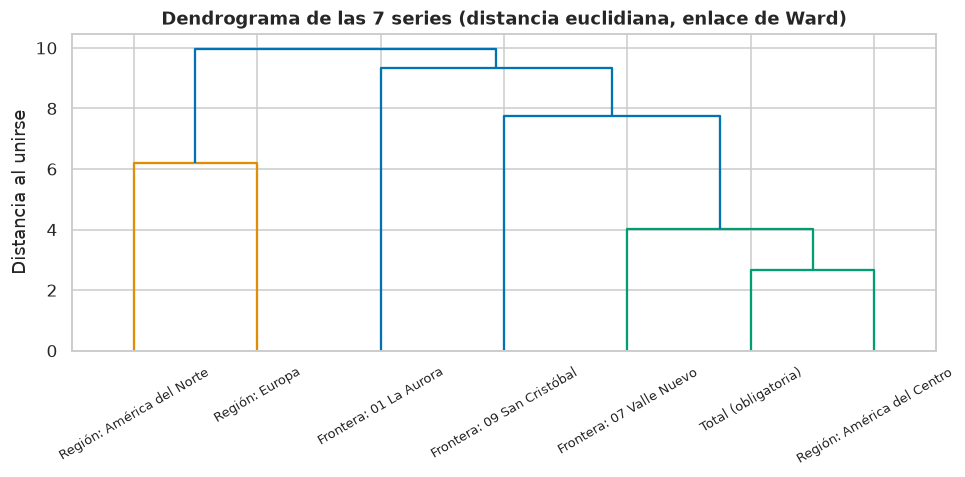

In [7]:
enlaces = linkage(matriz_std.values, method="ward")

fig, ax = plt.subplots(figsize=(9, 4.5))
dendrogram(enlaces, labels=list(matriz_std.index), ax=ax, leaf_rotation=30, leaf_font_size=8.5)
ax.set(title="Dendrograma de las 7 series (distancia euclidiana, enlace de Ward)",
       ylabel="Distancia al unirse")
plt.tight_layout()
plt.show()

In [8]:
siluetas = []
for k in range(2, 6):
    etiquetas_k = KMeans(n_clusters=k, n_init=25, random_state=SEMILLA).fit_predict(matriz_std.values)
    siluetas.append({"k": k, "silueta": silhouette_score(matriz_std.values, etiquetas_k)})
tabla_sil = pd.DataFrame(siluetas)
display(tabla_sil.style.format({"silueta": "{:.3f}"}).hide(axis="index"))

K = int(tabla_sil.loc[tabla_sil["silueta"].idxmax(), "k"])
print(f"Número de grupos con mejor silueta: k = {K}")

kmeans = KMeans(n_clusters=K, n_init=25, random_state=SEMILLA).fit(matriz_std.values)
grupos = pd.DataFrame({
    "serie": matriz_std.index,
    "categoría (Lab 1)": [du.CATEGORIAS[[k for k, v in du.NOMBRES.items() if v == e][0]]
                           for e in matriz_std.index],
    "grupo K-medias": kmeans.labels_,
    "grupo jerárquico": fcluster(enlaces, K, criterion="maxclust"),
    "PC1": coords[:, 0].round(2),
    "PC2": coords[:, 1].round(2),
})
display(grupos.sort_values("grupo K-medias").style.hide(axis="index"))
grupos.to_csv("../data/processed/grupos_catch22.csv", index=False)

k,silueta
2,0.207
3,0.247
4,0.253
5,0.207


Número de grupos con mejor silueta: k = 4


serie,categoría (Lab 1),grupo K-medias,grupo jerárquico,PC1,PC2
Frontera: 01 La Aurora,Fronteras,0,4,0.690000,-5.850000
Total (obligatoria),General,1,2,-2.890000,-0.140000
Frontera: 07 Valle Nuevo,Fronteras,1,2,-1.480000,1.040000
Región: América del Centro,Regiones,1,2,-2.910000,0.860000
Región: Europa,Regiones,2,1,4.270000,0.050000
Región: América del Norte,Regiones,2,1,3.590000,2.590000
Frontera: 09 San Cristóbal,Fronteras,3,3,-1.280000,1.440000


### 4.3 Mapa de calor de las características

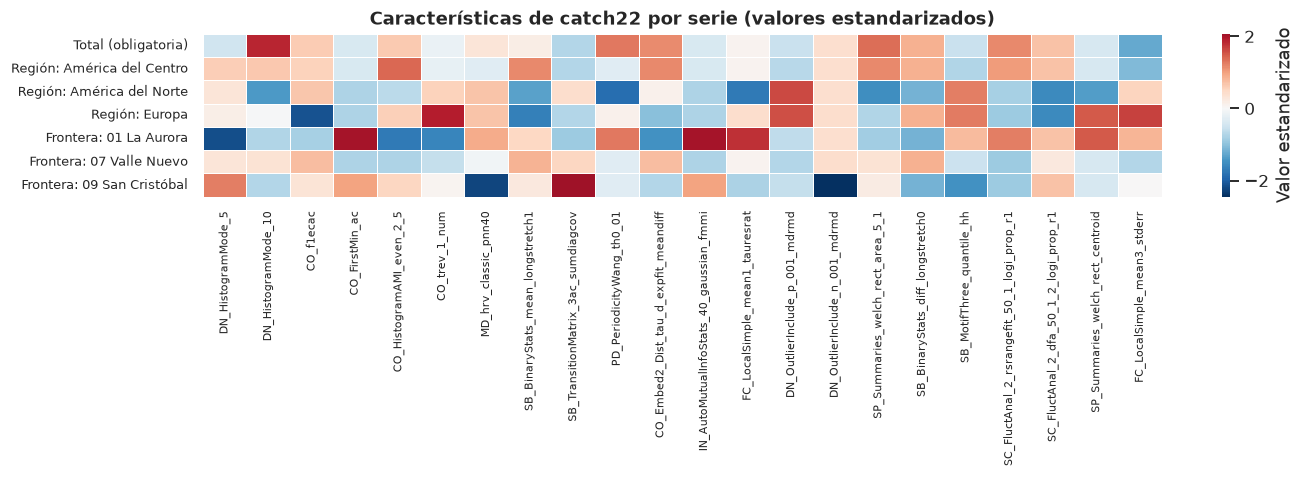

In [9]:
fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(matriz_std, cmap="RdBu_r", center=0, annot=False,
            cbar_kws={"label": "Valor estandarizado"}, ax=ax, linewidths=0.4)
ax.set(title="Características de catch22 por serie (valores estandarizados)", xlabel="", ylabel="")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=8.5)
plt.tight_layout()
plt.show()

El rojo indica que la serie tiene un valor **alto** en esa característica respecto de las
demás, y el azul un valor **bajo**. Las filas con patrones de color parecidos son las series
que catch22 considera similares.

### 4.4 Matriz de correlaciones entre características

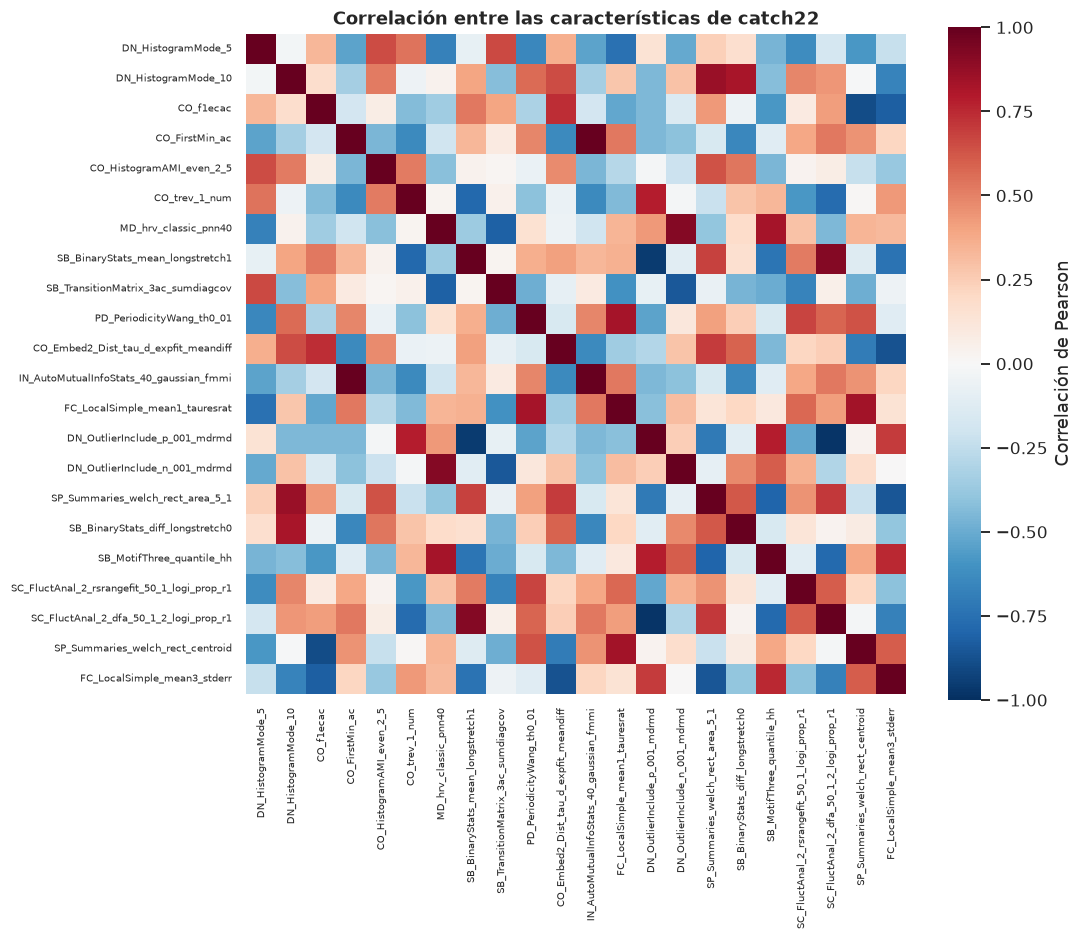

Parejas distintas de características: 231
  con |r| > 0.9:   5   (2%)
  con |r| > 0.7:  29   (13%)
  correlación absoluta mediana: 0.41

Las 6 parejas que más se repiten entre sí:
  +1.00   CO_FirstMin_ac  <->  IN_AutoMutualInfoStats_40_gaussian_fmmi
  -0.98   DN_OutlierInclude_p_001_mdrmd  <->  SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1
  -0.96   SB_BinaryStats_mean_longstretch1  <->  DN_OutlierInclude_p_001_mdrmd
  +0.92   SB_BinaryStats_mean_longstretch1  <->  SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1
  +0.92   MD_hrv_classic_pnn40  <->  DN_OutlierInclude_n_001_mdrmd
  -0.89   CO_f1ecac  <->  SP_Summaries_welch_rect_centroid


In [10]:
correlaciones = matriz_std.corr()

fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(correlaciones, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Correlación de Pearson"}, ax=ax)
ax.set_title("Correlación entre las características de catch22")
plt.xticks(rotation=90, fontsize=6.5)
plt.yticks(fontsize=6.5)
plt.tight_layout()
plt.show()

# Pares más correlacionados (en valor absoluto). Se toma solo el triángulo
# superior para no contar dos veces cada pareja ni la diagonal.
pares = correlaciones.where(np.triu(np.ones(correlaciones.shape), k=1).astype(bool)).stack().dropna()
print(f"Parejas distintas de características: {len(pares)}")
print(f"  con |r| > 0.9: {(pares.abs() > 0.9).sum():3d}   ({(pares.abs() > 0.9).mean():.0%})")
print(f"  con |r| > 0.7: {(pares.abs() > 0.7).sum():3d}   ({(pares.abs() > 0.7).mean():.0%})")
print(f"  correlación absoluta mediana: {pares.abs().median():.2f}\n")

print("Las 6 parejas que más se repiten entre sí:")
for (a, b), _ in pares.abs().sort_values(ascending=False).head(6).items():
    print(f"  {correlaciones.loc[a, b]:+.2f}   {a}  <->  {b}")

catch22 fue diseñado para que sus características se solaparan lo menos posible, y en general lo cumple. La correlación absoluta mediana entre parejas es moderada y solo un puñado de parejas supera 0.9. Esas pocas sí son casi intercambiables (el caso más extremo es `CO_FirstMin_ac` con `IN_AutoMutualInfoStats_40_gaussian_fmmi`, que miden lo mismo por dos caminos distintos: cuándo deja de parecerse la serie a sí misma), pero no son la norma.

### 4.5 Mapa de distancias entre series

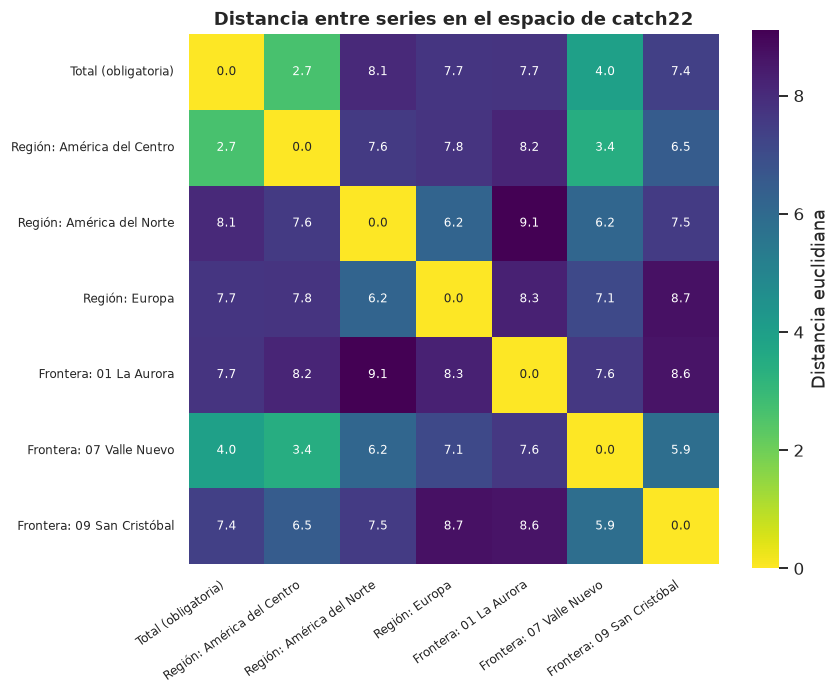

Par más parecido:  Total (obligatoria)  y  Región: América del Centro  (distancia 2.67)
Par más distinto:  Región: América del Norte  y  Frontera: 01 La Aurora  (distancia 9.11)


In [11]:
distancias = pd.DataFrame(squareform(pdist(matriz_std.values, metric="euclidean")),
                          index=matriz_std.index, columns=matriz_std.index)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(distancias, cmap="viridis_r", annot=True, fmt=".1f", square=True,
            cbar_kws={"label": "Distancia euclidiana"}, ax=ax, annot_kws={"size": 8})
ax.set(title="Distancia entre series en el espacio de catch22", xlabel="", ylabel="")
plt.xticks(rotation=35, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

sin_diagonal = distancias.where(np.triu(np.ones(distancias.shape), k=1).astype(bool)).stack()
print(f"Par más parecido:  {sin_diagonal.idxmin()[0]}  y  {sin_diagonal.idxmin()[1]}  (distancia {sin_diagonal.min():.2f})")
print(f"Par más distinto:  {sin_diagonal.idxmax()[0]}  y  {sin_diagonal.idxmax()[1]}  (distancia {sin_diagonal.max():.2f})")

## 5. Interpretación de los resultados (incisos 2.6 a 2.11)

### 5.1 ¿Cuáles series presentan comportamientos más similares? (inciso 2.7)

In [12]:
print("Las 3 parejas de series más parecidas (menor distancia en el espacio de catch22):\n")
for (a, b), d in sin_diagonal.sort_values().head(3).items():
    print(f"  distancia {d:5.2f}   {a}   <->   {b}")

print("\nComposición de los grupos encontrados:\n")
for g in sorted(grupos["grupo K-medias"].unique()):
    miembros = grupos[grupos["grupo K-medias"] == g]
    print(f"  Grupo {g}: {', '.join(miembros['serie'])}")

Las 3 parejas de series más parecidas (menor distancia en el espacio de catch22):

  distancia  2.67   Total (obligatoria)   <->   Región: América del Centro
  distancia  3.44   Región: América del Centro   <->   Frontera: 07 Valle Nuevo
  distancia  3.97   Total (obligatoria)   <->   Frontera: 07 Valle Nuevo

Composición de los grupos encontrados:

  Grupo 0: Frontera: 01 La Aurora
  Grupo 1: Total (obligatoria), Región: América del Centro, Frontera: 07 Valle Nuevo
  Grupo 2: Región: América del Norte, Región: Europa
  Grupo 3: Frontera: 09 San Cristóbal


Las tres piezas de evidencia apuntan en la misma dirección: las parejas de menor distancia
del mapa de calor son también las que se unen primero en el dendrograma y las que aparecen
más juntas en el plano del PCA.

### 5.2 ¿Qué características fueron las más importantes para diferenciar las series? (inciso 2.8)

La importancia se mide con las **cargas** (*loadings*) del PCA: qué tanto pesa cada
característica dentro de PC1 y PC2, que son los ejes que más separan a las series.

,PC1,PC2,importancia
DN_HistogramMode_5,-0.040,+0.359,+0.361
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,-0.330,-0.145,+0.360
FC_LocalSimple_mean1_tauresrat,-0.054,-0.354,+0.358
DN_OutlierInclude_p_001_mdrmd,+0.332,+0.129,+0.356
FC_LocalSimple_mean3_stderr,+0.334,-0.108,+0.351
SB_BinaryStats_mean_longstretch1,-0.327,-0.095,+0.340
SP_Summaries_welch_rect_area_5_1,-0.332,+0.056,+0.337
SB_MotifThree_quantile_hh,+0.321,-0.099,+0.336


Guardado: data/processed/importancia_catch22.csv (lo usa el notebook 03)


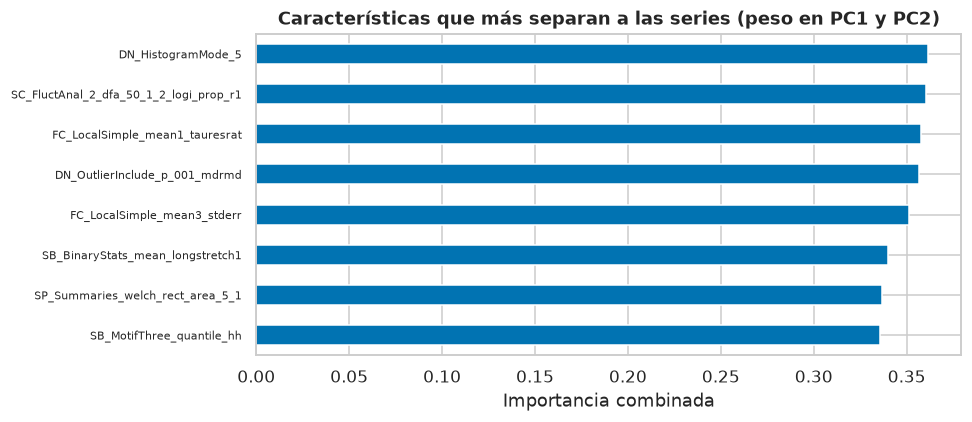

In [13]:
cargas = pd.DataFrame(pca.components_[:2].T, index=matriz_std.columns, columns=["PC1", "PC2"])
cargas["importancia"] = np.sqrt(cargas["PC1"] ** 2 + cargas["PC2"] ** 2)
cargas_ordenadas = cargas.sort_values("importancia", ascending=False)
top_cargas = cargas_ordenadas.head(8)
display(top_cargas.style.format("{:+.3f}"))
cargas_ordenadas.to_csv("../data/processed/importancia_catch22.csv")
print("Guardado: data/processed/importancia_catch22.csv (lo usa el notebook 03)")

fig, ax = plt.subplots(figsize=(9, 4))
top_cargas["importancia"].iloc[::-1].plot.barh(ax=ax, color="C0")
ax.set(title="Características que más separan a las series (peso en PC1 y PC2)",
       xlabel="Importancia combinada", ylabel="")
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.show()

In [14]:
# Diccionario de las características que suelen dominar, para poder interpretarlas.
GLOSARIO = {
    "DN_HistogramMode_5": "nivel más frecuente de la serie (moda con 5 clases)",
    "DN_HistogramMode_10": "nivel más frecuente de la serie (moda con 10 clases)",
    "CO_f1ecac": "cuántos meses tarda la autocorrelación en caer a 1/e: memoria de la serie",
    "CO_FirstMin_ac": "primer mínimo de la autocorrelación: medio ciclo del patrón repetitivo",
    "CO_HistogramAMI_even_2_5": "información mutua a 2 meses: dependencia no lineal de corto plazo",
    "CO_trev_1_num": "asimetría temporal: si la serie sube distinto de como baja",
    "MD_hrv_classic_pnn40": "proporción de cambios mes a mes grandes",
    "SB_BinaryStats_mean_longstretch1": "racha más larga de meses seguidos por encima de la media",
    "SB_BinaryStats_diff_longstretch0": "racha más larga de bajadas consecutivas",
    "SB_MotifThree_quantile_hh": "entropía de los patrones de 3 meses: qué tan variados son",
    "SB_TransitionMatrix_3ac_sumdiagcov": "qué tanto la serie se queda en el mismo nivel de un mes a otro",
    "FC_LocalSimple_mean1_tauresrat": "cuánto cambia la memoria de la serie al predecirla con el mes anterior",
    "FC_LocalSimple_mean3_stderr": "error de predecir con el promedio de los 3 meses previos",
    "SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1": "escalamiento de las fluctuaciones (DFA): ruido de corto vs. largo plazo",
    "SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1": "escalamiento del rango (tipo Hurst)",
    "SP_Summaries_welch_rect_area_5_1": "cuánta energía está en las frecuencias bajas (tendencia)",
    "SP_Summaries_welch_rect_centroid": "frecuencia dominante de la serie",
    "PD_PeriodicityWang_th0_01": "periodo dominante detectado, en meses",
    "IN_AutoMutualInfoStats_40_gaussian_fmmi": "primer mínimo de la información mutua",
    "DN_OutlierInclude_p_001_mdrmd": "influencia de los valores atípicos altos",
    "DN_OutlierInclude_n_001_mdrmd": "influencia de los valores atípicos bajos",
    "CO_Embed2_Dist_tau_d_expfit_meandiff": "qué tan regulares son los saltos entre meses",
}
faltantes = [c for c in matriz.columns if c not in GLOSARIO]
print(f"Características sin descripción en el glosario: {faltantes if faltantes else 'ninguna'}\n")

print("Qué miden las características más discriminantes:\n")
for nombre in top_cargas.index[:6]:
    print(f"  {nombre}")
    print(f"      -> {GLOSARIO.get(nombre, 'característica de catch22')}")
    ordenadas = matriz_util[nombre].sort_values()
    print(f"      valor más bajo: {ordenadas.index[0]} | más alto: {ordenadas.index[-1]}\n")

Características sin descripción en el glosario: ninguna

Qué miden las características más discriminantes:

  DN_HistogramMode_5
      -> nivel más frecuente de la serie (moda con 5 clases)
      valor más bajo: Frontera: 01 La Aurora | más alto: Frontera: 09 San Cristóbal

  SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1
      -> escalamiento de las fluctuaciones (DFA): ruido de corto vs. largo plazo
      valor más bajo: Región: Europa | más alto: Frontera: 09 San Cristóbal

  FC_LocalSimple_mean1_tauresrat
      -> cuánto cambia la memoria de la serie al predecirla con el mes anterior
      valor más bajo: Región: América del Norte | más alto: Frontera: 01 La Aurora

  DN_OutlierInclude_p_001_mdrmd
      -> influencia de los valores atípicos altos
      valor más bajo: Frontera: 07 Valle Nuevo | más alto: Región: América del Norte

  FC_LocalSimple_mean3_stderr
      -> error de predecir con el promedio de los 3 meses previos
      valor más bajo: Total (obligatoria) | más alto: Región: Eur

### 5.3 ¿Existen grupos naturales? (inciso 2.9)

El dendrograma y el coeficiente de silueta son la evidencia. Un valor de silueta claramente
por encima de 0 indica que los grupos están razonablemente separados; cerca de 0 significa
que las series forman más bien un continuo y la división es arbitraria.

In [15]:
print(f"Mejor silueta: {tabla_sil['silueta'].max():.3f} con k = {K} grupos.\n")

perfil = matriz_std.copy()
perfil["grupo"] = kmeans.labels_
medias_grupo = perfil.groupby("grupo").mean()

print("Qué distingue a cada grupo (características con el valor promedio más extremo):\n")
for g in medias_grupo.index:
    miembros = ", ".join(grupos[grupos["grupo K-medias"] == g]["serie"])
    print(f"Grupo {g} — {miembros}")
    extremos = medias_grupo.loc[g].abs().sort_values(ascending=False).head(3)
    for nombre in extremos.index:
        signo = "alto" if medias_grupo.loc[g, nombre] > 0 else "bajo"
        print(f"   {signo:5} en {nombre}: {GLOSARIO.get(nombre, '')}")
    print()

Mejor silueta: 0.253 con k = 4 grupos.

Qué distingue a cada grupo (características con el valor promedio más extremo):

Grupo 0 — Frontera: 01 La Aurora
   bajo  en DN_HistogramMode_5: nivel más frecuente de la serie (moda con 5 clases)
   alto  en CO_FirstMin_ac: primer mínimo de la autocorrelación: medio ciclo del patrón repetitivo
   alto  en IN_AutoMutualInfoStats_40_gaussian_fmmi: primer mínimo de la información mutua

Grupo 1 — Total (obligatoria), Región: América del Centro, Frontera: 07 Valle Nuevo
   alto  en CO_Embed2_Dist_tau_d_expfit_meandiff: qué tan regulares son los saltos entre meses
   bajo  en FC_LocalSimple_mean3_stderr: error de predecir con el promedio de los 3 meses previos
   alto  en SP_Summaries_welch_rect_area_5_1: cuánta energía está en las frecuencias bajas (tendencia)

Grupo 2 — Región: América del Norte, Región: Europa
   alto  en DN_OutlierInclude_p_001_mdrmd: influencia de los valores atípicos altos
   bajo  en SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1: es

### 5.4 ¿Las series de una misma categoría tienden a agruparse? (inciso 2.10)

Se compara el grupo asignado por catch22 contra la categoría de origen (Regiones vs.
Fronteras vs. la serie total).

In [16]:
tabla_cruzada = pd.crosstab(grupos["categoría (Lab 1)"], grupos["grupo K-medias"])
display(tabla_cruzada)

coinciden = 0
for cat in grupos["categoría (Lab 1)"].unique():
    sub = grupos[grupos["categoría (Lab 1)"] == cat]
    if len(sub) > 1 and sub["grupo K-medias"].nunique() == 1:
        coinciden += 1
        print(f"  La categoría '{cat}' quedó completamente dentro de un solo grupo.")
    elif len(sub) > 1:
        print(f"  La categoría '{cat}' quedó repartida en {sub['grupo K-medias'].nunique()} grupos.")

if coinciden == 0:
    print("\nNinguna categoría del Laboratorio 1 se conserva intacta como grupo de catch22:")
    print("las series se agrupan por cómo se comportan, no por la clasificación administrativa.")

grupo K-medias,0,1,2,3
categoría (Lab 1),,,,
Fronteras,1,1,0,1
General,0,1,0,0
Regiones,0,1,2,0


  La categoría 'Regiones' quedó repartida en 2 grupos.
  La categoría 'Fronteras' quedó repartida en 3 grupos.

Ninguna categoría del Laboratorio 1 se conserva intacta como grupo de catch22:
las series se agrupan por cómo se comportan, no por la clasificación administrativa.


La lectura de fondo es la siguiente: **Regiones** y **Fronteras** son categorías administrativas (de dónde viene el viajero y por dónde entra) y no hay ninguna razón para que impliquen dinámicas temporales iguales. Una frontera aérea como La Aurora se parece más, en su comportamiento mensual, a las regiones que dependen de vuelos (Europa, América del Norte) que a un paso terrestre como San Cristóbal, aunque administrativamente las tres fronteras vayan juntas.

### 5.5 ¿Cuál es la serie más atípica? (inciso 2.11)

Se mide qué tan lejos está cada serie del resto: su distancia promedio a las otras seis y su
distancia al centro de la nube.

In [17]:
centro = matriz_std.values.mean(axis=0)
atipicidad = pd.DataFrame({
    "distancia media al resto": (distancias.sum(axis=1) / (len(distancias) - 1)),
    "distancia al centro": np.linalg.norm(matriz_std.values - centro, axis=1),
}, index=matriz_std.index).sort_values("distancia media al resto", ascending=False)
display(atipicidad.style.format("{:.2f}"))

mas_atipica = atipicidad.index[0]
print(f"Serie más atípica: {mas_atipica}\n")
print("Características en las que más se aparta del promedio de las 7 series:")
desvios = matriz_std.loc[mas_atipica].abs().sort_values(ascending=False).head(5)
for nombre in desvios.index:
    valor = matriz_std.loc[mas_atipica, nombre]
    print(f"  {valor:+.2f} desviaciones en {nombre}")
    print(f"      -> {GLOSARIO.get(nombre, 'característica de catch22')}")

,distancia media al resto,distancia al centro
Frontera: 01 La Aurora,8.26,6.05
Región: Europa,7.63,5.33
Región: América del Norte,7.44,5.14
Frontera: 09 San Cristóbal,7.44,5.13
Total (obligatoria),6.26,3.92
Región: América del Centro,6.02,3.62
Frontera: 07 Valle Nuevo,5.69,2.79


Serie más atípica: Frontera: 01 La Aurora

Características en las que más se aparta del promedio de las 7 series:
  -2.15 desviaciones en DN_HistogramMode_5
      -> nivel más frecuente de la serie (moda con 5 clases)
  +2.02 desviaciones en CO_FirstMin_ac
      -> primer mínimo de la autocorrelación: medio ciclo del patrón repetitivo
  +2.02 desviaciones en IN_AutoMutualInfoStats_40_gaussian_fmmi
      -> primer mínimo de la información mutua
  +1.79 desviaciones en FC_LocalSimple_mean1_tauresrat
      -> cuánto cambia la memoria de la serie al predecirla con el mes anterior
  -1.74 desviaciones en CO_HistogramAMI_even_2_5
      -> información mutua a 2 meses: dependencia no lineal de corto plazo


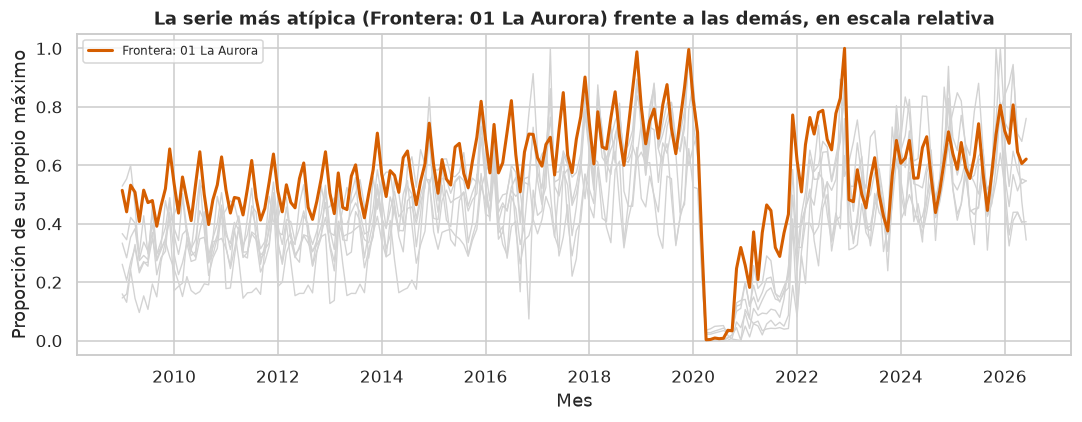

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
for clave, s in series.items():
    etiqueta = du.NOMBRES[clave]
    destacar = etiqueta == mas_atipica
    ax.plot(s.index, s.values / s.max(), lw=2.0 if destacar else 0.9,
            color="C3" if destacar else "lightgrey", zorder=3 if destacar else 1,
            label=etiqueta if destacar else None)
ax.set(title=f"La serie más atípica ({mas_atipica}) frente a las demás, en escala relativa",
       xlabel="Mes", ylabel="Proporción de su propio máximo")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

El gráfico normaliza cada serie por su propio máximo, para que la comparación sea de forma y
no de tamaño. Así se ve directamente qué es lo que hace distinta a la serie que catch22
señaló como atípica.

## 6. Comparación contra el análisis exploratorio del Laboratorio 1 (inciso 2.12)

En el Laboratorio 1 cada serie se caracterizó con cuatro medidas obtenidas de la
descomposición: fuerza de tendencia, fuerza estacional, volatilidad del residuo e impacto de
la pandemia. Se recalculan aquí con la misma función y se cruzan contra los grupos de
catch22.

In [19]:
caracterizacion = pd.DataFrame([
    tsu.caracterizar_serie(du.NOMBRES[clave], s, periodo=12) for clave, s in series.items()
]).set_index("serie")
caracterizacion["grupo catch22"] = grupos.set_index("serie")["grupo K-medias"]

display(caracterizacion.style.format({
    "fuerza_tendencia": "{:.2f}", "fuerza_estacional": "{:.2f}",
    "volatilidad_residuo": "{:.3f}", "impacto_pandemia_pct": "{:.1f}%",
}))

,fuerza_tendencia,fuerza_estacional,volatilidad_residuo,impacto_pandemia_pct,grupo catch22
serie,,,,,
Total (obligatoria),0.86,0.50,0.134,97.2%,1
Región: América del Centro,0.84,0.45,0.157,96.4%,1
Región: América del Norte,0.88,0.70,0.126,100.0%,2
Región: Europa,0.81,0.73,0.154,100.0%,2
Frontera: 01 La Aurora,0.82,0.56,0.118,99.6%,0
Frontera: 07 Valle Nuevo,0.80,0.37,0.206,99.9%,1
Frontera: 09 San Cristóbal,0.75,0.30,0.270,100.0%,3


In [20]:
print("Promedio de cada medida del Laboratorio 1, por grupo de catch22:\n")
resumen_grupos = caracterizacion.groupby("grupo catch22")[
    ["fuerza_tendencia", "fuerza_estacional", "volatilidad_residuo", "impacto_pandemia_pct"]
].mean()
display(resumen_grupos.style.format({
    "fuerza_tendencia": "{:.2f}", "fuerza_estacional": "{:.2f}",
    "volatilidad_residuo": "{:.3f}", "impacto_pandemia_pct": "{:.1f}%",
}))

print("\nCorrelación entre la posición en PC1/PC2 y las medidas del Laboratorio 1:")
posiciones = pd.DataFrame(coords[:, :2], index=matriz_std.index, columns=["PC1", "PC2"])
juntos = posiciones.join(caracterizacion)
correl_lab1 = juntos.corr().loc[
    ["PC1", "PC2"],
    ["fuerza_tendencia", "fuerza_estacional", "volatilidad_residuo", "impacto_pandemia_pct"],
]
display(correl_lab1.style.format("{:+.2f}"))

Promedio de cada medida del Laboratorio 1, por grupo de catch22:



,fuerza_tendencia,fuerza_estacional,volatilidad_residuo,impacto_pandemia_pct
grupo catch22,,,,
0,0.82,0.56,0.118,99.6%
1,0.83,0.44,0.166,97.8%
2,0.84,0.71,0.140,100.0%
3,0.75,0.30,0.270,100.0%



Correlación entre la posición en PC1/PC2 y las medidas del Laboratorio 1:


,fuerza_tendencia,fuerza_estacional,volatilidad_residuo,impacto_pandemia_pct
PC1,+0.13,+0.83,-0.31,+0.68
PC2,+0.07,-0.11,+0.41,-0.02


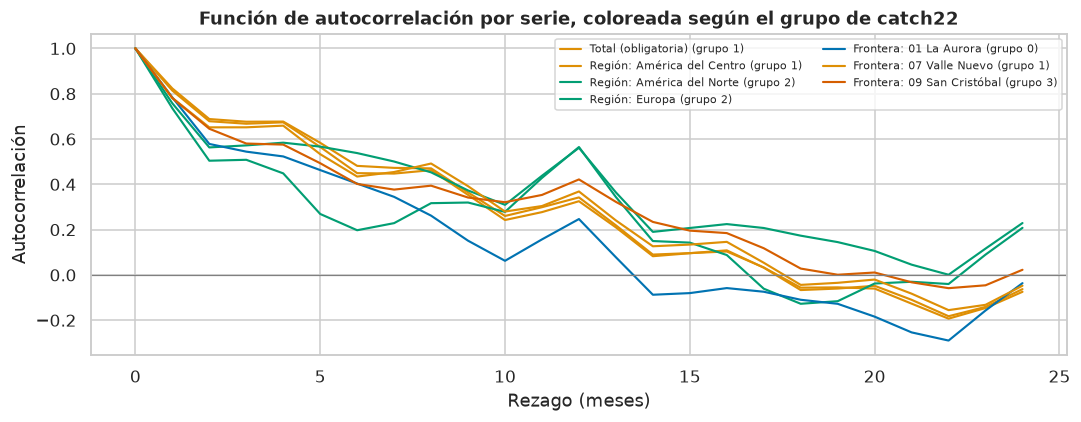

In [21]:
# Autocorrelación de las series, coloreada por el grupo que encontró catch22.
fig, ax = plt.subplots(figsize=(10, 4))
paleta = sns.color_palette("colorblind", K)
for clave, s in series.items():
    etiqueta = du.NOMBRES[clave]
    g = grupos.set_index("serie").loc[etiqueta, "grupo K-medias"]
    valores_acf = acf(s.dropna(), nlags=24)
    ax.plot(range(len(valores_acf)), valores_acf, lw=1.4, color=paleta[g], label=f"{etiqueta} (grupo {g})")
ax.axhline(0, color="grey", lw=0.8)
ax.set(title="Función de autocorrelación por serie, coloreada según el grupo de catch22",
       xlabel="Rezago (meses)", ylabel="Autocorrelación")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

**¿Son consistentes los agrupamientos con lo observado en el Laboratorio 1?**

En buena parte sí, y la tabla de correlaciones lo cuantifica punto por punto:

- **Estacionalidad: muy consistente.** `PC1` correlaciona **+0.83** con la fuerza estacional.
  Es decir, el eje que más separa a las series en el espacio de catch22 es esencialmente el
  mismo que el Laboratorio 1 identificó como la principal diferencia entre ellas, y catch22
  llegó ahí sin que nadie le dijera que buscara estacionalidad. Se ve en los grupos: América
  del Norte y Europa, las dos series más estacionales, quedan juntas en un extremo de PC1.
- **Impacto de la pandemia: consistente, pero por arrastre.** Correlaciona **+0.68** con PC1.
  El detalle es que esta medida casi no varía entre series (todas cayeron entre 96 % y 100 %),
  así que la correlación se explica sobre todo porque las series más estacionales son también
  las que cayeron al 100 %, no porque catch22 esté midiendo la pandemia por separado.
- **Tendencia: sin relación.** Correlación de apenas **+0.13** con PC1. No es que catch22 la
  ignore, es que en el Laboratorio 1 las 7 series tenían fuerza de tendencia casi idéntica
  (0.75 a 0.88): una medida que no varía no puede separar nada.
- **Volatilidad: aparece en el segundo eje.** Correlaciona **−0.31** con PC1 pero **+0.41**
  con PC2. El Laboratorio 1 la resumió en un solo número; catch22 la reparte entre varias
  características (rachas, cambios grandes, atípicos), de modo que dos series con volatilidad
  parecida pueden separarse si su ruido tiene forma distinta.
- **Autocorrelación: consistente.** El último gráfico es la comprobación más directa. Las
  series del mismo color tienen curvas de ACF con forma parecida, así que catch22 está
  capturando la misma estructura de dependencia temporal que se veía en los correlogramas del
  Laboratorio 1.

## 7. Tres descubrimientos que no eran evidentes en el análisis tradicional (inciso 2.13)

In [22]:
# Insumos numéricos para los tres hallazgos.
print("1) ¿Cuánto de cada eje del PCA explica el análisis del Laboratorio 1?\n")
resumen_ejes = pd.DataFrame({
    "varianza explicada": pca.explained_variance_ratio_[:3],
    "máx. |correlación| con una medida del Lab 1": [
        correl_lab1.loc[eje].abs().max() if eje in correl_lab1.index else np.nan
        for eje in ["PC1", "PC2", "PC3"]
    ],
}, index=["PC1", "PC2", "PC3"])
# PC3 no estaba en la tabla de correlaciones; se calcula aquí.
pc3 = pd.Series(coords[:, 2], index=matriz_std.index, name="PC3")
resumen_ejes.loc["PC3", "máx. |correlación| con una medida del Lab 1"] = (
    pd.concat([pc3, caracterizacion.drop(columns="grupo catch22")], axis=1)
      .corr().loc["PC3"].drop("PC3").abs().max()
)
display(resumen_ejes.style.format({"varianza explicada": "{:.1%}",
                                   "máx. |correlación| con una medida del Lab 1": "{:.2f}"}))

print("\n2) La serie más atípica según catch22, vista con las medidas del Laboratorio 1:\n")
orden_lab1 = caracterizacion[["fuerza_tendencia", "fuerza_estacional",
                              "volatilidad_residuo", "impacto_pandemia_pct"]]
rangos = orden_lab1.rank()            # 1 = el valor más bajo de las 7 series
rangos["distancia media al resto (catch22)"] = atipicidad["distancia media al resto"].rank(ascending=False)
print("Puesto de cada serie en cada medida (1 = valor más bajo de las 7):")
display(rangos.astype(int))

print("\n3) Composición de los grupos frente a la categoría administrativa:\n")
for g in sorted(grupos["grupo K-medias"].unique()):
    sub = grupos[grupos["grupo K-medias"] == g]
    cats = ", ".join(sorted(set(sub["categoría (Lab 1)"])))
    print(f"  Grupo {g}: {', '.join(sub['serie'])}")
    print(f"           categorías del Lab 1 mezcladas en él: {cats}")

1) ¿Cuánto de cada eje del PCA explica el análisis del Laboratorio 1?



,varianza explicada,máx. |correlación| con una medida del Lab 1
PC1,33.9%,0.83
PC2,29.1%,0.41
PC3,21.5%,0.63



2) La serie más atípica según catch22, vista con las medidas del Laboratorio 1:

Puesto de cada serie en cada medida (1 = valor más bajo de las 7):


,fuerza_tendencia,fuerza_estacional,volatilidad_residuo,impacto_pandemia_pct,distancia media al resto (catch22)
serie,,,,,
Total (obligatoria),6,4,3,2,5
Región: América del Centro,5,3,5,1,6
Región: América del Norte,7,6,2,6,3
Región: Europa,3,7,4,6,2
Frontera: 01 La Aurora,4,5,1,3,1
Frontera: 07 Valle Nuevo,2,2,6,4,7
Frontera: 09 San Cristóbal,1,1,7,5,4



3) Composición de los grupos frente a la categoría administrativa:

  Grupo 0: Frontera: 01 La Aurora
           categorías del Lab 1 mezcladas en él: Fronteras
  Grupo 1: Total (obligatoria), Región: América del Centro, Frontera: 07 Valle Nuevo
           categorías del Lab 1 mezcladas en él: Fronteras, General, Regiones
  Grupo 2: Región: América del Norte, Región: Europa
           categorías del Lab 1 mezcladas en él: Regiones
  Grupo 3: Frontera: 09 San Cristóbal
           categorías del Lab 1 mezcladas en él: Fronteras


Los tres descubrimientos, basados en las salidas anteriores:

1. **Hay un segundo eje de comportamiento que el análisis clásico no podía ver.** `PC1`
   coincide casi por completo con la estacionalidad que ya medía el Laboratorio 1
   (correlación 0.83), así que ahí catch22 confirma lo conocido. Pero `PC2` explica un 29 %
   adicional de la variación, es independiente de PC1 por construcción, y **ninguna de las
   cuatro medidas del Laboratorio 1 lo explica bien**; su correlación más alta es apenas 0.41,
   con la volatilidad. Existe entonces una segunda dimensión en la que estas series difieren
   (relacionada con la forma del ruido y la duración de las rachas, no con su temporada alta)
   que la descomposición en tendencia, estacionalidad y residuo no tenía cómo expresar,
   porque justamente empaqueta todo eso en un solo número.

2. **La serie que parecía más "promedio" resulta ser la más atípica.** La Aurora no destacaba
   en nada en el Laboratorio 1. Su tendencia, su estacionalidad y su impacto pandémico están
   en la mitad de la tabla, y de hecho era la serie *menos* volátil de las siete. Con catch22
   es la más alejada de todas las demás, y por un margen amplio. Está a más de dos
   desviaciones del promedio en el primer mínimo de su autocorrelación, es decir su patrón
   repetitivo tiene un medio ciclo más largo que el del resto. En otras palabras, La Aurora es la
   única frontera **aérea** de las tres, y su ritmo anual (dos temporadas altas marcadas de
   viaje internacional) es distinto del de los pasos terrestres, donde el flujo es más
   cotidiano. Ese rasgo no aparecía en ninguna de las cuatro medidas en laboratorio anterior.

3. **Los grupos de comportamiento cruzan las categorías administrativas.** La serie total,
   América del Centro y Valle Nuevo caen en el mismo grupo pese a pertenecer a categorías
   distintas. Las tres describen movilidad terrestre regional, y la serie total se parece
   sobre todo a América del Centro simplemente porque esa región aporta la mayor parte de su
   volumen (es, de hecho, la pareja más cercana de las 21 posibles). En el otro grupo quedan
   América del Norte y Europa, los mercados de largo radio que dependen de vuelos. Ni
   *Regiones* ni *Fronteras* sobreviven como grupo. El Laboratorio 1 analizó estas series
   siempre dentro de su categoría, así que este parecido cruzado no podía surgir de aquel
   análisis, es consecuencia directa de mirar a las siete series en un mismo espacio.